# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсоток даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)

In [2]:
# Завантажуємо дані
df = pd.read_csv('../data/credit_risk_dataset.csv')

print(f"Розмір датасету: {df.shape}")
print(f"Кількість клієнтів: {df.shape[0]:,}")
print(f"Кількість ознак: {df.shape[1]}")
print()
df.info()
df.head()

Розмір датасету: (32581, 12)
Кількість клієнтів: 32,581
Кількість ознак: 12

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Перевірка пропущених значень
missing = df.isnull().sum()
missing[missing > 0]

person_emp_length     895
loan_int_rate        3116
dtype: int64

In [4]:
# Розподіл даних
loan_status_dist = df['loan_status'].value_counts()
loan_status_percent = df['loan_status'].value_counts(normalize=True) * 100

loan_status_percent

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

**Висновок**

Датасет містить 32 581 запис і 12 ознак. Після першого огляду видно, що в даних є пропущені значення у двох колонках:

- `person_emp_length` — 895 пропущених значень;
- `loan_int_rate` — 3 116 пропущених значень.

Цільова змінна `loan_status` має два класи:
- `0` — кредит сплачено: приблизно 78%;
- `1` — дефолт: приблизно 22%.

Отже, задача є задачею незбалансованої класифікації, оскільки класів не порівну: клієнтів без дефолту значно більше, ніж клієнтів з дефолтом.


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [5]:
# 1. % пропущених значень в колонках

missing_val = round(missing[missing > 0] / len(df) * 100, 2)
print(missing_val)

person_emp_length    2.75
loan_int_rate        9.56
dtype: float64


У датасеті є пропущені значення у двох числових колонках:
- `person_emp_length` — 2.75%;
- `loan_int_rate` — 9.56%.

Оскільки це числові змінні, пропущені значення заповнюємо медіаною.

In [6]:
# Заповнюємо пропуски медіаною для числових колонок
num_missing_cols = ['person_emp_length', 'loan_int_rate']

df[num_missing_cols] = df[num_missing_cols].fillna(df[num_missing_cols].median())

# Перевіряємо, чи залишились пропуски
df[num_missing_cols].isnull().sum()

person_emp_length    0
loan_int_rate        0
dtype: int64

In [7]:
# 2. Статистика по числових змінних

df.select_dtypes("number").describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.77,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.09,6322.09,3.08,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,8.49,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.11,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


За описовою статистикою видно, що числові змінні мають різні масштаби. 
Наприклад, `person_income` має дуже велике максимальне значення — 6 000 000, 
що може свідчити про наявність викидів. Також у колонці `person_age` максимальне значення 144, що виглядає нетипово.

In [8]:
# 3. Пошук викидів у person_income методом IQR

Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Нижня межа:", lower_bound)
print("Верхня межа:", upper_bound)

income_outliers = df[(df['person_income'] < lower_bound) | (df['person_income'] > upper_bound)]

print("Кількість викидів:", income_outliers.shape[0])
print("Відсоток викидів:", round(income_outliers.shape[0] / len(df) * 100, 2), "%")

Q1: 38500.0
Q3: 79200.0
IQR: 40700.0
Нижня межа: -22550.0
Верхня межа: 140250.0
Кількість викидів: 1484
Відсоток викидів: 4.55 %


In [9]:
# Обробляємо викиди: значення вище верхньої межі замінюємо на upper_bound

df['person_income_clean'] = df['person_income'].clip(lower=lower_bound, upper=upper_bound)

df[['person_income', 'person_income_clean']].describe().round(2)

,person_income,person_income_clean
count,32581.00,32581.00
mean,66074.85,62419.21
std,61983.12,31810.27
min,4000.00,4000.00
25%,38500.00,38500.00
50%,55000.00,55000.00
75%,79200.00,79200.00
max,6000000.00,140250.00


У колонці `person_income` були знайдені викиди за методом IQR. 
Щоб не втрачати дані, я не видаляла рядки, а обмежила екстремальні значення верхньою межею IQR. 
Для подальшого аналізу створено нову колонку `person_income_clean`.

In [10]:
# 4. Аналіз категоріальних змінних

cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    print(f"\nКолонка: {col}")
    
    cat_analysis = (
        df.groupby(col)
        .agg(
            count=('loan_status', 'count'),
            default_rate=('loan_status', 'mean')
        )
        .sort_values('default_rate', ascending=False)
    )
    
    display(cat_analysis.round(3))


Колонка: person_home_ownership


,count,default_rate
person_home_ownership,,
RENT,16446,0.316
OTHER,107,0.308
MORTGAGE,13444,0.126
OWN,2584,0.075



Колонка: loan_intent


,count,default_rate
loan_intent,,
DEBTCONSOLIDATION,5212,0.286
MEDICAL,6071,0.267
HOMEIMPROVEMENT,3605,0.261
PERSONAL,5521,0.199
EDUCATION,6453,0.172
VENTURE,5719,0.148



Колонка: loan_grade


,count,default_rate
loan_grade,,
G,64,0.984
F,241,0.705
E,964,0.644
D,3626,0.590
C,6458,0.207
B,10451,0.163
A,10777,0.100



Колонка: cb_person_default_on_file


,count,default_rate
cb_person_default_on_file,,
Y,5745,0.378
N,26836,0.184


In [11]:
# Створюємо текстову версію цільової змінної для графіків

df['loan_status_label'] = df['loan_status'].map({
    0: 'No default',
    1: 'Default'
})

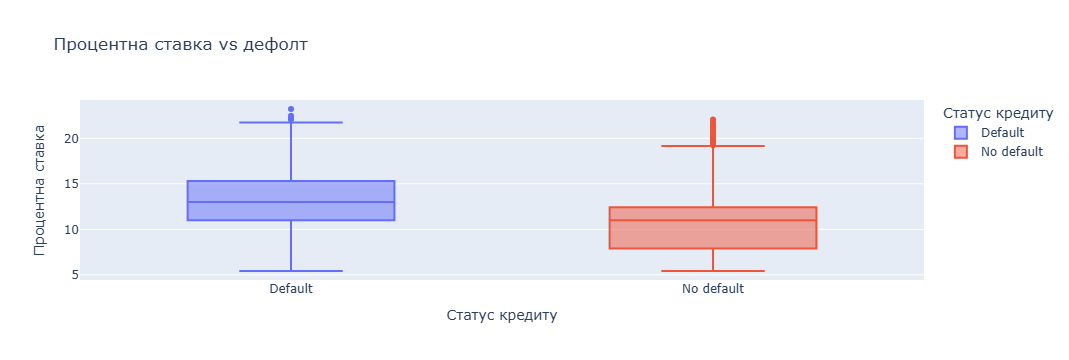

In [12]:
# 5. Візуалізація зв’язку ознак з цільовою змінною

# Loan interest rate vs loan_status

fig = px.box(
    df,
    x='loan_status_label',
    y='loan_int_rate',
    color='loan_status_label',
    title='Процентна ставка vs дефолт',
    labels={
        'loan_int_rate': 'Процентна ставка',
        'loan_status_label': 'Статус кредиту'
    }
)

fig.show()

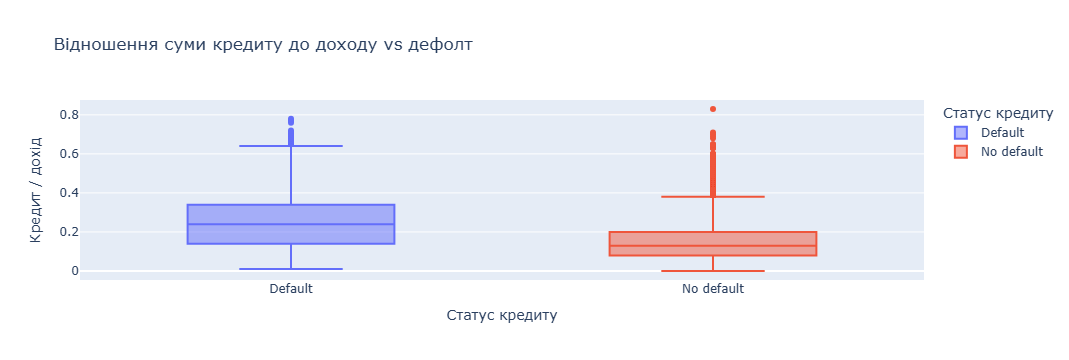

In [13]:
# Loan percent income vs loan_status

fig = px.box(
    df,
    x='loan_status_label',
    y='loan_percent_income',
    color='loan_status_label',
    title='Відношення суми кредиту до доходу vs дефолт',
    labels={
        'loan_percent_income': 'Кредит / дохід',
        'loan_status_label': 'Статус кредиту'
    }
)

fig.show()

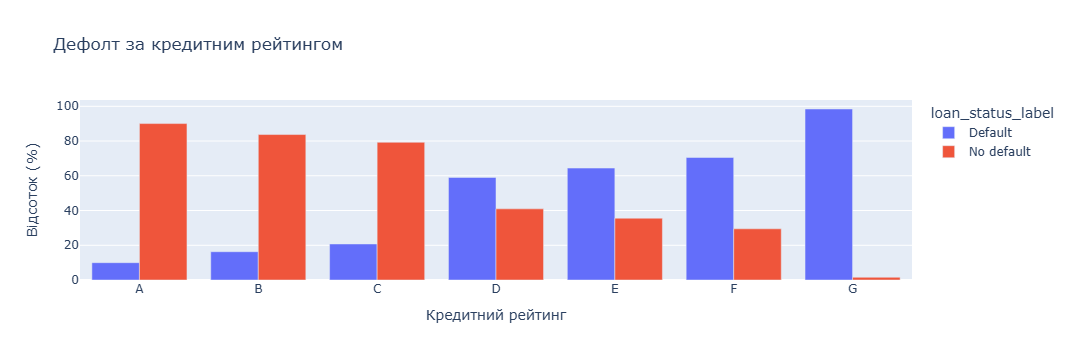

In [14]:
# Дефолт за кредитним рейтингом

grade_status = df.groupby(['loan_grade', 'loan_status_label']).size().unstack()

grade_status_pct = grade_status.div(grade_status.sum(axis=1), axis=0) * 100

fig = px.bar(
    grade_status_pct,
    title='Дефолт за кредитним рейтингом',
    labels={
        'value': 'Відсоток (%)',
        'loan_grade': 'Кредитний рейтинг'
    },
    barmode='group'
)

fig.show()

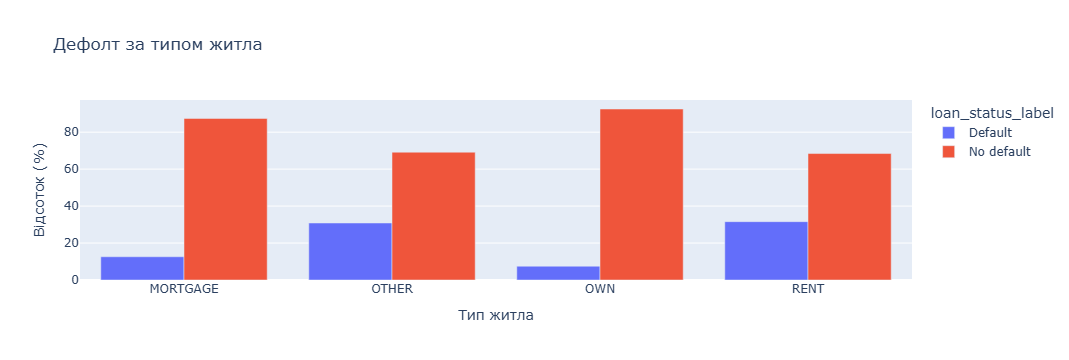

In [15]:
# Дефолт за типом житла

home_status = df.groupby(['person_home_ownership', 'loan_status_label']).size().unstack()

home_status_pct = home_status.div(home_status.sum(axis=1), axis=0) * 100

fig = px.bar(
    home_status_pct,
    title='Дефолт за типом житла',
    labels={
        'value': 'Відсоток (%)',
        'person_home_ownership': 'Тип житла'
    },
    barmode='group'
)

fig.show()

**Висновок**

Під час дослідницького аналізу було виявлено, що в датасеті є пропущені значення у двох числових колонках, які були заповнені медіаною. Також у колонці `person_income` були знайдені викиди, тому для подальшого аналізу створено очищену колонку `person_income_clean`.

За графіками видно, що з дефолтом можуть бути пов’язані такі ознаки, як процентна ставка, відношення суми кредиту до доходу, кредитний рейтинг та тип володіння житлом. Наприклад, клієнти з нижчим кредитним рейтингом мають вищу частку дефолтів.

Отже, ці змінні можуть бути корисними для побудови моделі прогнозування кредитного ризику.


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



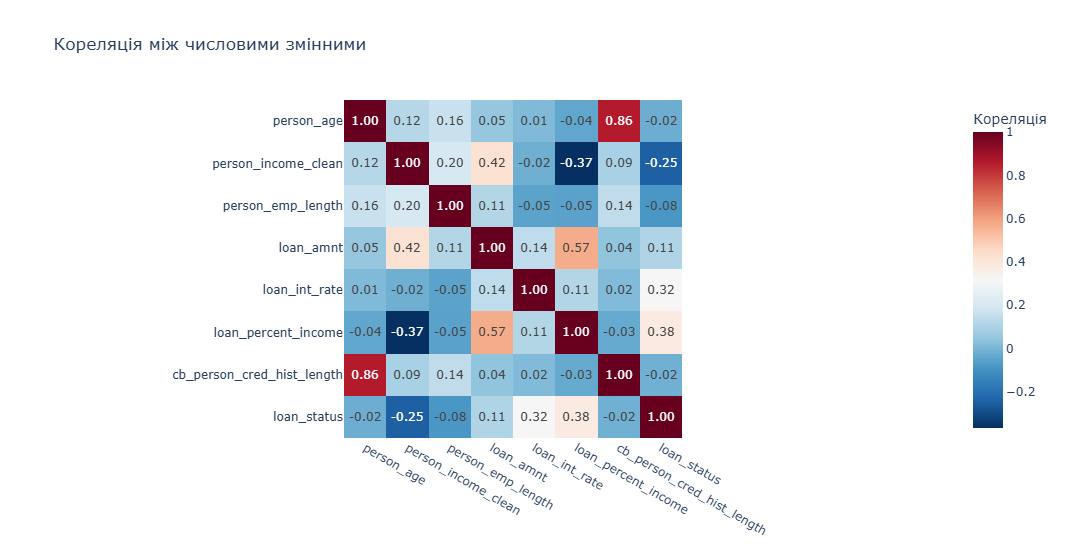

In [16]:
# 1. Матриця кореляцій для числових змінних

metrics_df = df[
    [
        'person_age',
        'person_income_clean',
        'person_emp_length',
        'loan_amnt',
        'loan_int_rate',
        'loan_percent_income',
        'cb_person_cred_hist_length',
        'loan_status'
    ]
]

correlation_matrix = metrics_df.corr()

fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між числовими змінними',
    labels=dict(color='Кореляція')
)

fig.update_layout(height=550)
fig.show()

За матрицею кореляцій видно, що найпомітніший зв’язок із цільовою змінною `loan_status` мають:

- `loan_percent_income` — позитивна кореляція;
- `loan_int_rate` — позитивна кореляція;
- `person_income_clean` — від’ємна кореляція;
- `loan_amnt` — слабка позитивна кореляція.

Це означає, що більша частка кредиту відносно доходу та вища процентна ставка можуть бути пов’язані з вищою ймовірністю дефолту. Також видно, що більший дохід має від’ємний зв’язок із дефолтом. Сума кредиту теж може мати вплив, але напряму її кореляція з цільовою змінною слабша.

In [17]:
# 2. Кодування категоріальних змінних

model_df = df[
    [
        'person_age',
        'person_income_clean',
        'person_emp_length',
        'loan_intent',
        'loan_grade',
        'loan_amnt',
        'loan_int_rate',
        'loan_percent_income',
        'person_home_ownership',
        'cb_person_default_on_file',
        'cb_person_cred_hist_length',
        'loan_status'
    ]
].copy()

# Вибираємо категоріальні колонки для кодування
cat_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

# One-hot encoding
df_encoded = pd.get_dummies(
    model_df,
    columns=cat_cols,
    drop_first=True
)

df_encoded.head()

,person_age,person_income_clean,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,1,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0.10,2,0,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,1,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,0.53,2,1,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,0.55,4,1,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True


In [18]:
# Перетворюємо boolean-колонки в 0/1

bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.head()

,person_age,person_income_clean,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1
1,21,9600,5.0,1000,11.14,0.10,2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0
2,25,9600,1.0,5500,12.87,0.57,3,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
3,23,65500,4.0,35000,15.23,0.53,2,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0
4,24,54400,8.0,35000,14.27,0.55,4,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1


In [19]:
# 3. Фінальний набір ознак

exclude_cols = ['loan_status', 'person_income', 'loan_status_label']

feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

X = df_encoded[feature_cols]
y = df_encoded['loan_status']

print(f"Кількість ознак: {X.shape[1]}")
print(f"Розмір вибірки: {X.shape[0]}")

Кількість ознак: 22
Розмір вибірки: 32581


Для моделювання було сформовано набір ознак `X` та цільову змінну `y`. 
Цільова змінна `loan_status` була виключена з ознак, оскільки саме її потрібно прогнозувати.

Також було виключено початкову колонку `person_income`, оскільки для аналізу та моделі використовується очищена колонка `person_income_clean`, де були оброблені викиди.

У фінальному наборі залишено числові ознаки та закодовані категоріальні змінні, оскільки вони можуть бути корисними для прогнозування кредитного ризику.

In [20]:
X.head()

,person_age,person_income_clean,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1
1,21,9600,5.0,1000,11.14,0.10,2,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0
2,25,9600,1.0,5500,12.87,0.57,3,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
3,23,65500,4.0,35000,15.23,0.53,2,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0
4,24,54400,8.0,35000,14.27,0.55,4,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1


**Висновок**

Було побудовано матрицю кореляцій для числових змінних. Найбільш помітний зв’язок із цільовою змінною `loan_status` мають `loan_percent_income` та `loan_int_rate`. Також `person_income_clean` має від’ємну кореляцію з дефолтом, а `loan_amnt` — слабку позитивну кореляцію.

Категоріальні змінні були закодовані методом One-Hot Encoding за допомогою `pd.get_dummies()`. Boolean-колонки після кодування були перетворені у формат 0/1.

Для подальшого навчання моделі було сформовано фінальний набір ознак `X` та цільову змінну `y`. Цільова змінна `loan_status` була виключена з ознак, оскільки саме її потрібно прогнозувати.

У фінальному наборі залишено всі основні числові ознаки та закодовані категоріальні змінні, оскільки вони можуть бути корисними для прогнозування кредитного ризику.


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [21]:
# 1-2. Розділення на навчальну та тестову вибірки

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # зберігаємо пропорції класів
)

print(f"Train: {X_train.shape[0]} клієнтів")
print(f"Test: {X_test.shape[0]} клієнтів")
print(f"Дефолт у train: {y_train.mean():.1%}")
print(f"Дефолт у test: {y_test.mean():.1%}")

Train: 26064 клієнтів
Test: 6517 клієнтів
Дефолт у train: 21.8%
Дефолт у test: 21.8%


In [22]:
# 3. Масштабування

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# 4. Створення та навчання моделі логістичній регресії

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Модель навчена!")
model

Модель навчена!


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [24]:
# 5. Прогнозування на тренувальній та тестовій вибірках

# Прогнози класів
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Прогнози ймовірностей
y_train_pred_proba = model.predict_proba(X_train_scaled)
y_test_pred_proba = model.predict_proba(X_test_scaled)

print("Прогнози зроблено для train та test вибірок")

Прогнози зроблено для train та test вибірок


In [25]:
# Приклад прогнозів для перших 5 клієнтів тестової вибірки

sample_predictions = pd.DataFrame({
    'Реальний статус': y_test.values[:5],
    'Прогноз': y_test_pred[:5],
    'Ймовірність без дефолту': y_test_pred_proba[:5, 0].round(3),
    'Ймовірність дефолту': y_test_pred_proba[:5, 1].round(3)
})

sample_predictions

,Реальний статус,Прогноз,Ймовірність без дефолту,Ймовірність дефолту
0,0,0,0.887,0.113
1,0,0,0.911,0.089
2,0,0,0.992,0.008
3,0,0,0.927,0.073
4,0,0,0.994,0.006


**Висновок**

Дані були розділені на навчальну та тестову вибірки у співвідношенні 80/20. 
Параметр `stratify=y` дозволив зберегти однакову частку дефолтів у train та test вибірках — приблизно 21.8%.

Після цього ознаки були масштабовані за допомогою `StandardScaler`. Масштабування виконувалось коректно: scaler навчався тільки на тренувальній вибірці, а потім застосовувався до тестової.

Було навчено модель логістичної регресії та зроблено прогнози класів і ймовірностей для тренувальної та тестової вибірок.


---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


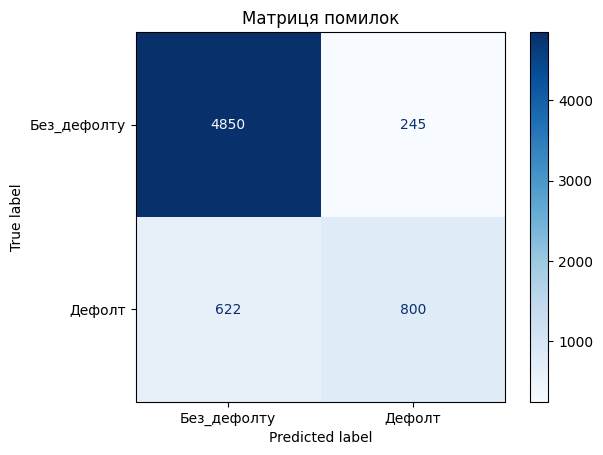

In [26]:
# 1. Побудуова confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Без_дефолту', 'Дефолт'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()

За матрицею помилок видно, що модель добре визначає клієнтів без дефолту: 4850 клієнтів були класифіковані правильно. Також модель правильно визначила 800 клієнтів з дефолтом.

Водночас 622 дефолтні клієнти були помилково віднесені до класу без дефолту. Для задачі кредитного ризику це важливо, оскільки пропущений дефолт може бути більш критичним для бізнесу.

In [27]:
# 2. Основні метрики (accuracy, precision, recall, f1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"Accuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):    0.867
Precision (Влучність):  0.766
Recall (Повнота):       0.563
F1-score:               0.649


Модель має досить високу загальну точність — accuracy = 0.867. Precision = 0.766 означає, що серед клієнтів, яких модель визначила як дефолтних, приблизно 76.6% справді мають дефолт.

Recall = 0.563 показує, що модель знаходить приблизно 56.3% усіх дефолтних клієнтів. Для задачі кредитного ризику це середній результат, оскільки частина ризикових клієнтів залишається непоміченою.

F1-score = 0.649 показує баланс між precision та recall.

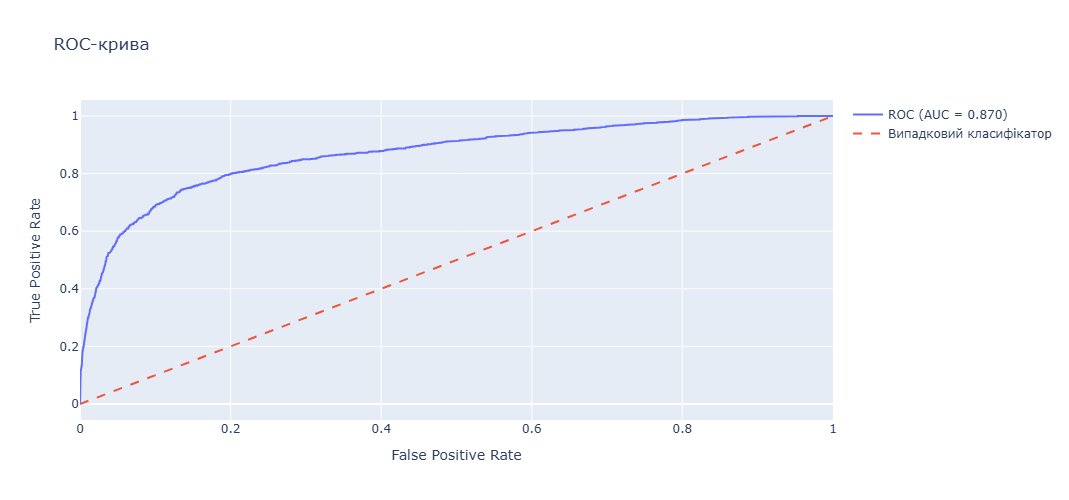

In [28]:
# 3. Побудова ROC-кривої та обчислення AUC

from sklearn.metrics import roc_curve, roc_auc_score

# Обчислюємо ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_test_pred_proba[:, 1])

# Візуалізація
fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC = {auc:.3f})'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'),
                        name='Випадковий класифікатор'))
fig.update_layout(
    title='ROC-крива',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500
)
fig.show()

**Інтерпретація AUC:**
- AUC = 0.5 — модель не краща за випадкове вгадування
- AUC = 0.7-0.8 — прийнятна модель
- AUC = 0.8-0.9 — хороша модель
- AUC > 0.9 — відмінна модель

ROC-AUC = 0.870, що свідчить про хорошу здатність моделі розділяти клієнтів з дефолтом та без дефолту. Модель працює значно краще, ніж випадковий класифікатор.

In [29]:
# 4. Аналіз важливості ознак

# Отримуємо коефіцієнти моделі
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model. coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
5,loan_percent_income,1.254270,1.254270
17,loan_grade_D,0.822317,0.822317
18,loan_grade_E,0.481755,0.481755
3,loan_amnt,-0.467390,0.467390
8,person_home_ownership_OWN,-0.445162,0.445162
9,person_home_ownership_RENT,0.420598,0.420598
14,loan_intent_VENTURE,-0.411387,0.411387
10,loan_intent_EDUCATION,-0.319694,0.319694
19,loan_grade_F,0.282783,0.282783
20,loan_grade_G,0.273675,0.273675


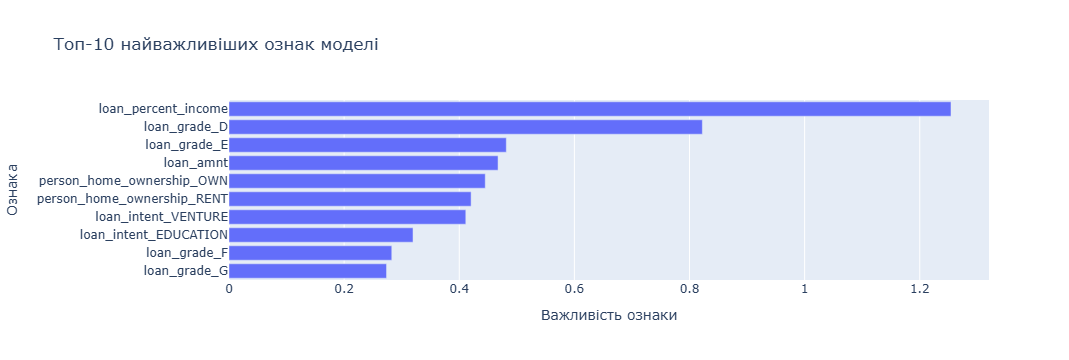

In [30]:
# Топ-10 найважливіших ознак за абсолютним значенням коефіцієнта

top_features = feature_importance.head(10)

fig = px.bar(
    top_features,
    x='abs_coefficient',
    y='feature',
    orientation='h',
    title='Топ-10 найважливіших ознак моделі',
    labels={
        'abs_coefficient': 'Важливість ознаки',
        'feature': 'Ознака'
    }
)

fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

Найбільший вплив на прогноз мають `loan_percent_income`, кредитний рейтинг (`loan_grade_D`, `loan_grade_E`) та сума кредиту `loan_amnt`.

Найважливішою ознакою є `loan_percent_income`, тобто відношення суми кредиту до доходу клієнта. Це логічно, оскільки чим більша частка кредиту відносно доходу, тим вищим може бути ризик дефолту.

**Висновок**

Модель логістичної регресії показала хороший загальний результат: accuracy = 0.867, ROC-AUC = 0.870. Це означає, що модель добре розділяє клієнтів з дефолтом та без дефолту.

Водночас recall = 0.563 показує, що модель знаходить не всі випадки дефолту. Для задачі кредитного ризику це важливо, адже пропущений дефолт може бути критичним для бізнесу.

Найбільш важливими ознаками для прогнозу стали `loan_percent_income`, кредитний рейтинг, сума кредиту та тип володіння житлом. Отже, модель загалом працює добре, але для бізнес-задачі може бути корисно додатково оптимізувати поріг класифікації, щоб краще знаходити дефолтних клієнтів.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



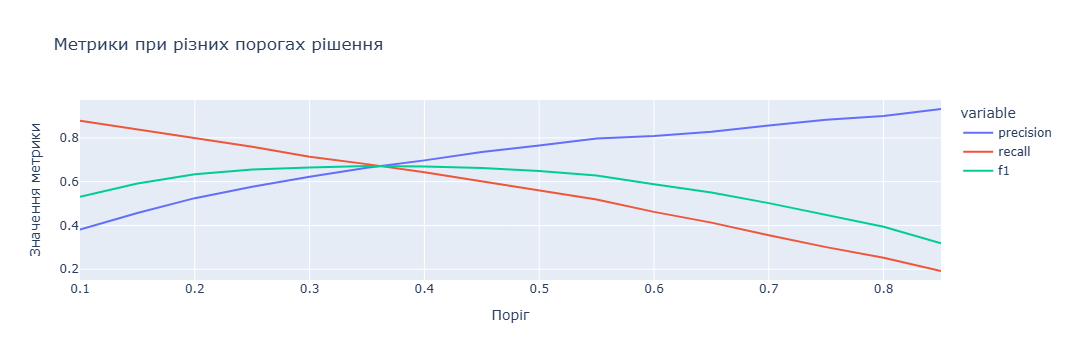

In [31]:
# Аналіз різних порогів

thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_test_pred_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

# Візуалізація
fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах рішення',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг'},
)
fig.show()

In [32]:
# Сортуємо за F1-score, щоб знайти найкращий поріг

metrics_df.sort_values('f1', ascending=False).head(10).round(3)

,threshold,precision,recall,f1
5,0.35,0.663,0.680,0.672
6,0.40,0.697,0.643,0.669
4,0.30,0.622,0.714,0.665
7,0.45,0.736,0.601,0.662
3,0.25,0.577,0.759,0.656
8,0.50,0.766,0.563,0.649
2,0.20,0.525,0.801,0.634
9,0.55,0.797,0.518,0.628
1,0.15,0.457,0.839,0.592
10,0.60,0.808,0.462,0.588


In [33]:
# Поріг з максимальним F1-score

best_row = metrics_df.loc[metrics_df['f1'].idxmax()]

print("Найкращий поріг за F1-score:")
print(best_row.round(3))

Найкращий поріг за F1-score:
threshold    0.350
precision    0.663
recall       0.680
f1           0.672
Name: 5, dtype: float64


In [34]:
# Обираємо оптимальний поріг

optimal_threshold = 0.35

y_test_pred_optimal = (y_test_pred_proba[:, 1] >= optimal_threshold).astype(int)

print("Обраний поріг:", optimal_threshold)

Обраний поріг: 0.35


In [35]:
# Метрики при оптимальному порозі

accuracy_opt = accuracy_score(y_test, y_test_pred_optimal)
precision_opt = precision_score(y_test, y_test_pred_optimal)
recall_opt = recall_score(y_test, y_test_pred_optimal)
f1_opt = f1_score(y_test, y_test_pred_optimal)

print("Метрики при оптимальному порозі:")
print(f"Accuracy: {accuracy_opt:.3f}")
print(f"Precision: {precision_opt:.3f}")
print(f"Recall: {recall_opt:.3f}")
print(f"F1-score: {f1_opt:.3f}")

Метрики при оптимальному порозі:
Accuracy: 0.855
Precision: 0.663
Recall: 0.680
F1-score: 0.672


**Висновок**

Було проаналізовано метрики `precision`, `recall` та `F1-score` при різних порогах класифікації.

З графіка видно, що при збільшенні порогу `precision` зростає, тобто модель стає обережнішою і відносить до дефолтних лише тих клієнтів, у яких ймовірність дефолту вища. Водночас `recall` зменшується, тобто модель знаходить менше реальних дефолтних клієнтів.

Для задачі кредитного ризику важливо не пропускати ризикових клієнтів, тому занадто високий поріг не підходить. Оптимальним для цієї задачі обрано поріг `0.35`, оскільки він дає кращий баланс між `precision` та `recall` і має високий `F1-score`.

Отже, для бізнес-задачі доцільно використовувати поріг `0.35`, щоб модель краще виявляла клієнтів з ризиком дефолту.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Поріг класифікації з попереднього завдання
threshold = 0.35

results = []

# 1. Logistic Regression — використовуємо масштабовані дані
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_proba = log_model.predict_proba(X_test_scaled)[:, 1]
log_pred = (log_proba >= threshold).astype(int)

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, log_pred),
    'Precision': precision_score(y_test, log_pred),
    'Recall': recall_score(y_test, log_pred),
    'F1': f1_score(y_test, log_pred),
    'AUC': roc_auc_score(y_test, log_proba)
})

# 2. Decision Tree — можна без масштабування
tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_model.fit(X_train, y_train)

tree_proba = tree_model.predict_proba(X_test)[:, 1]
tree_pred = (tree_proba >= threshold).astype(int)

results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, tree_pred),
    'Precision': precision_score(y_test, tree_pred),
    'Recall': recall_score(y_test, tree_pred),
    'F1': f1_score(y_test, tree_pred),
    'AUC': roc_auc_score(y_test, tree_proba)
})

# 3. Random Forest — можна без масштабування
forest_model = RandomForestClassifier(random_state=42, n_estimators=100)
forest_model.fit(X_train, y_train)

forest_proba = forest_model.predict_proba(X_test)[:, 1]
forest_pred = (forest_proba >= threshold).astype(int)

results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, forest_pred),
    'Precision': precision_score(y_test, forest_pred),
    'Recall': recall_score(y_test, forest_pred),
    'F1': f1_score(y_test, forest_pred),
    'AUC': roc_auc_score(y_test, forest_proba)
})

results_df = pd.DataFrame(results).round(3)
display(results_df)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.855,0.663,0.680,0.672,0.870
1,Decision Tree,0.882,0.731,0.726,0.728,0.874
2,Random Forest,0.918,0.845,0.766,0.804,0.930


**Висновок**

Було навчено та порівняно три моделі: Logistic Regression, Decision Tree та Random Forest.

Для порівняння моделей використано поріг класифікації `0.35`, який був обраний у попередньому завданні як оптимальний для бізнес-задачі.

Найкращий результат на тестовій вибірці показала модель `Random Forest`. Вона має найкращі значення основних метрик, зокрема `F1-score` та `AUC`.

Для задачі кредитного ризику важливим є `Recall`, оскільки потрібно виявляти якомога більше клієнтів з ризиком дефолту. Random Forest краще знаходить дефолтних клієнтів порівняно з Logistic Regression та Decision Tree.

Отже, серед трьох моделей найкращою для цієї задачі є `Random Forest`.

**Time spent — 4 год**

**What I learned**

- Розібралась із задачею класифікації: модель прогнозує клас, наприклад `дефолт / без дефолту`.
- Зрозуміла різницю між регресією та класифікацією: регресія прогнозує числове значення, а класифікація — категорію об’єкта.
- Попрактикувала базовий цикл ML-задачі:
  - дослідницький аналіз даних (EDA): перевірка пропусків, викидів, розподілів і зв’язку ознак із цільовою змінною;
  - підготовка даних;
  - навчання моделі;
  - оцінка якості.
- Заповнювала пропущені значення, обробляла викиди та кодувала категоріальні змінні.
- Навчила модель логістичної регресії та оцінила її через `accuracy`, `precision`, `recall`, `F1-score`, `ROC-AUC`.
- Розібралась, як зміна порогу класифікації впливає на `precision` і `recall`.
- Порівняла кілька моделей і побачила, що `Random Forest` показав найкращий результат.